In [1]:
from starccato_flow.supernovae.supernovae import Supernovae
from starccato_flow.plotting.sky import plot_galactic_supernovae_polar_hemispheres

import numpy as np
import healpy as hp

MPS device found
630763148.816


In [2]:
font_name = "Futura"
font_family = "sans-serif"

✓ Loaded 1934076 supernova locations from /Users/tarineccleston/Desktop/starccato/starccato-flow/../data/supernovae/exploded_supernovae_t100_sf5.csv
68% Credible Level: 38.0 deg²
90% Credible Level: 74.0 deg²
95% Credible Level: 87.1 deg²

Credible Area Labels:
  95% : 87.1 deg²
  90% : 74.0 deg²
  68% : 38.0 deg²


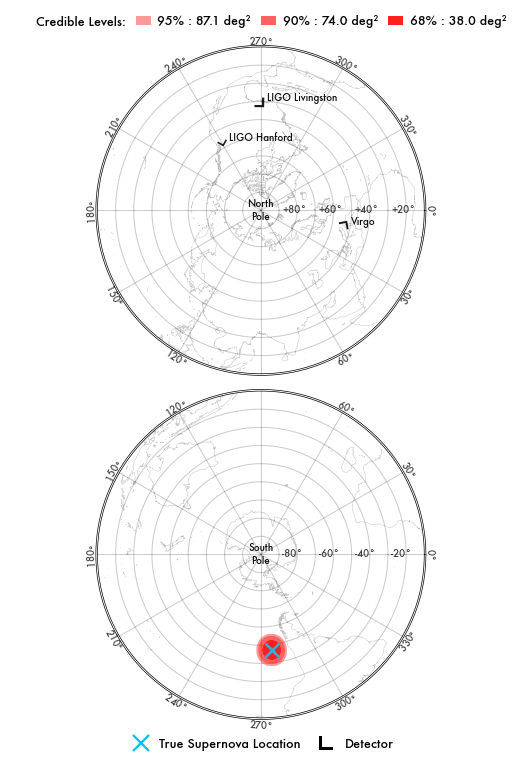

In [3]:
ccsn = Supernovae(complex=True)  # Use a rotation offset of 90 degrees for the galactic plane

# Use a location close to the galactic center but offset by ~10 degrees
gc_ra, gc_dec = ccsn.get_galactic_center_direction()
true_ra = gc_ra + np.deg2rad(10.0)  # Offset ~10 degrees in RA
true_dec = gc_dec - np.deg2rad(8.0)  # Offset ~8 degrees in Dec

# Generate example posterior samples around this location
np.random.seed(42)
n_posterior_samples = 5000

# Create a slightly spread-out posterior around the location
ra_posterior = np.random.normal(true_ra, 0.05, n_posterior_samples)
dec_posterior = np.random.normal(true_dec, 0.05, n_posterior_samples)

# Calculate credible areas using HEALPix
posterior_samples = np.column_stack([ra_posterior, dec_posterior])

# HEALPix parameters
nside = 256
pixel_area_deg2 = hp.nside2pixarea(nside, degrees=True)

# Convert RA/Dec to HEALPix theta/phi
theta = np.pi / 2 - dec_posterior
phi = np.mod(ra_posterior, 2 * np.pi)

# Assign each sample to a pixel
pixels = hp.ang2pix(nside, theta, phi)

# Create posterior probability map
npix = hp.nside2npix(nside)
counts = np.bincount(pixels, minlength=npix)
posterior = counts.astype(float)
posterior /= posterior.sum()

# Sort pixels by posterior probability and compute cumulative distribution
sorted_prob = np.sort(posterior)[::-1]
cumulative = np.cumsum(sorted_prob)

# Compute credible areas for 68%, 90%, 95%
credible_levels = (0.68, 0.90, 0.95)
credible_areas = {}
credible_area_labels = {}

for level in credible_levels:
    # Number of pixels needed to reach this probability
    n_pixels = np.searchsorted(cumulative, level) + 1
    area = n_pixels * pixel_area_deg2
    credible_areas[level] = area
    credible_area_labels[level] = f"{int(100*level)}% : {area:.1f} deg²"
    print(f"{int(100*level)}% Credible Level: {area:.1f} deg²")

print("\nCredible Area Labels:")
for level in sorted(credible_area_labels.keys(), reverse=True):
    print(f"  {credible_area_labels[level]}")

plot_galactic_supernovae_polar_hemispheres(
    ccsn,
    posterior_ra_samples=ra_posterior,
    posterior_dec_samples=dec_posterior,
    true_ra_override=true_ra,
    true_dec_override=true_dec,
    show_constellation_borders=False,
    show_stars=False,
    constellations=False,
    show_detectors=True,
    format="thesis",
    fname="../../2025-Statistics-Masters-Thesis/figures/sky-localisation/example_sky_localisation_lv.pdf",
    transparent=False,
    background="white",
    font_family=font_family,
    coastline=True,
    n_background_supernovae=0,
    galaxy=False,
    font_name=font_name,
    credible_area_labels=credible_area_labels,
)

### Add, Push, Commit

In [4]:
import subprocess

# Add all files
subprocess.run(["git", "pull"], cwd="../../2025-Statistics-Masters-Thesis")
subprocess.run(["git", "add", "."], cwd="../../2025-Statistics-Masters-Thesis")
# Commit
subprocess.run(["git", "commit", "-m", "Update Plots"], cwd="../../2025-Statistics-Masters-Thesis")
# Push
subprocess.run(["git", "push"], cwd="../../2025-Statistics-Masters-Thesis")

Already up to date.
[main 3f8b371] Update Plots
 1 file changed, 0 insertions(+), 0 deletions(-)


To github.com:the-tarin/2025-Statistics-Masters-Thesis.git
   8fcc6e6..3f8b371  main -> main


CompletedProcess(args=['git', 'push'], returncode=0)